## 1. Κατεβάζουμε τα δεδομένα

In [4]:
# import important python libraries
import pandas as pd # used for data manipulation and analysis.
import numpy as np # used for numerical computations.
import matplotlib.pyplot as plt # used for data visualization.


In [5]:
np.random.seed(42)
file_path = 'hard_train_data.csv'
df = pd.read_csv(file_path)
# Display the first few rows of the dataframe
pd.set_option('display.min_rows', 15)

print(df.shape) # displays the number of rows and columns of the array
df # prints the actual data

(800, 6)


,study_hours,attendance,sleep_hours,assignments_completed,stress_level,pass
0,2.254133,0.482969,8.902769,0.226079,0.839100,0
1,5.545634,0.021269,4.490352,0.264276,0.201528,1
2,11.970081,0.769223,4.072619,0.823552,0.819625,0
3,10.262452,0.375888,7.003621,0.164406,0.706372,0
4,17.959755,0.732225,5.497277,0.624874,0.153900,1
5,13.774073,0.231947,4.737524,0.483181,0.934544,0
6,19.582383,0.009332,7.041523,0.916421,0.342930,0
...,...,...,...,...,...,...
793,1.294797,0.878516,9.456728,0.609697,0.208315,1
794,24.512162,0.346100,5.605556,0.750770,0.270559,0


In [6]:
print(df.info()) # provides a concise summary of the DataFrame, including the number of non-null entries and data types of each column. 
print(df.columns) # prints the column names of the DataFrame.
df['pass'].value_counts() # counts the occurrences of each unique value in the 'pass' column, which is likely the target variable for classification.

X = df[['study_hours', 'attendance']].values # creates a feature matrix X that contains the values of the 'study_hours' and 'attendance' columns from df, which will be used as input features for the model.
y = df['pass'].values # creates a Series y that contains the 'pass' column from df, which will be used as the target variable for the model.

print('x and y shapes:')
print(X.shape) # displays the number of rows and columns in the feature matrix X.
print(y.shape) # displays the number of rows in the target vector y.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   study_hours            800 non-null    float64
 1   attendance             800 non-null    float64
 2   sleep_hours            800 non-null    float64
 3   assignments_completed  800 non-null    float64
 4   stress_level           800 non-null    float64
 5   pass                   800 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 37.6 KB
None
Index(['study_hours', 'attendance', 'sleep_hours', 'assignments_completed',
       'stress_level', 'pass'],
      dtype='object')
x and y shapes:
(800, 2)
(800,)


In [7]:
# find X's study hours min and max values for each column
print('X study hours min and max values:')
print(X[:, 0].min()) # displays the minimum value of the first column (study_hours) in the feature matrix X.
print(X[:, 0].max()) # displays the maximum value of the first column (study_hours) in the feature matrix X.
print('X attendance min and max values:')
print(X[:, 1].min()) # displays the minimum value of the second column (attendance) in the feature matrix X.
print(X[:, 1].max()) # displays the maximum value of the second column (attendance) in the feature matrix X.


X study hours min and max values:
0.1389606901380857
29.991530198583916
X attendance min and max values:
0.0032182636042786
0.9994137257706666


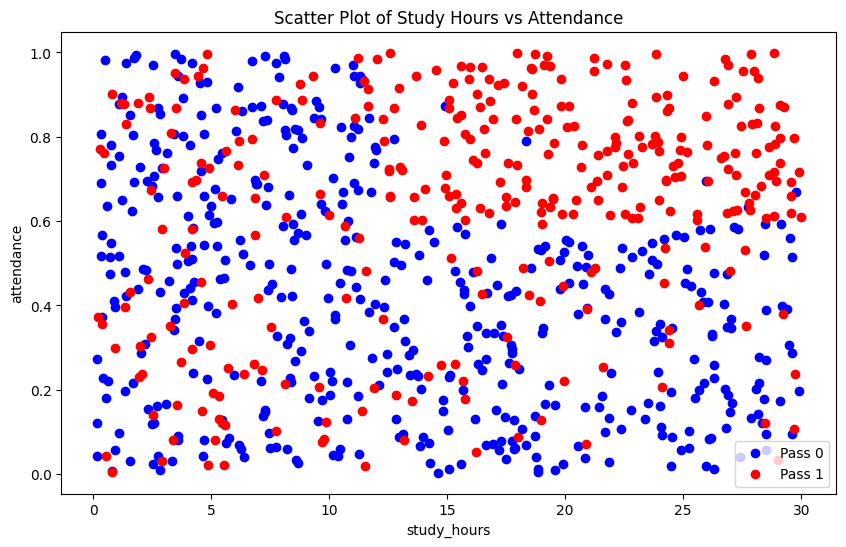

In [8]:
# Create a scatter plot (διάγραμμα διασποράς)
plt.figure(figsize=(10, 6)) 
plt.scatter(X[y == 0, 0], X[y == 0, 1], color='blue', label='Pass 0') 
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='red', label='Pass 1')
# Adding labels and title
plt.xlabel('study_hours')
plt.ylabel('attendance')
plt.title('Scatter Plot of Study Hours vs Attendance')
plt.legend()
plt.show() # plot current figure to screen


In [9]:
# import the necessary libraries
from sklearn import tree #import the tree module from the scikit-learn library
from sklearn.tree import DecisionTreeClassifier # used to create a decision tree classifier
from sklearn.metrics import accuracy_score # used to calculate the accuracy of a classification model


In [10]:
# Create a Decision Tree Classifier
d=1
for d in range(1, 2): # iterates over a range of values from 1 to 5 (inclusive) and assigns each value to the variable d in each iteration
    model = DecisionTreeClassifier(max_depth=d, random_state=42) # initializes a Decision Tree Classifier with a
    model.fit(X, y) # fits the decision tree model to the training data X and target variable y
    y_pred = model.predict(X) # uses the fitted model to make predictions on the training data
    accuracy = accuracy_score(y, y_pred) # calculates the accuracy of the model by comparing the true labels y with the predicted labels y_pred
    print(f'Accuracy: {accuracy:.2f}') # prints the accuracy of the model formatted to two decimal places
# # Visualize the Decision Tree
# plt.figure(figsize=(12, 8)) # creates a new figure with a specified size of 12 inches in width and 8 inches in height
# tree.plot_tree(model, filled=True) # visualizes the structure of the decision tree model, where filled=True colors the nodes based on the majority class in each node
# plt.title('Decision Tree Visualization') # sets the title of the plot
# plt.show() # displays the plot on the screen 

Accuracy: 0.73


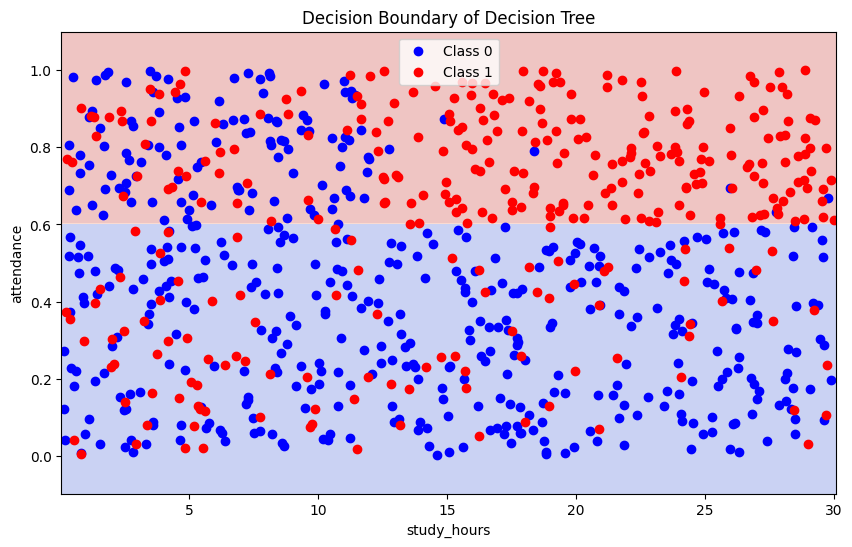

In [11]:
# Create a mesh grid over the feature space
padding = 0.1
x_min, x_max = X[:, 0].min() - padding, X[:, 0].max() + padding
y_min, y_max = X[:, 1].min() - padding, X[:, 1].max() + padding

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# Predict over the grid
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid_points)
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

# Plot the actual data points
plt.scatter(X[y == 0, 0], X[y == 0, 1], color='blue', label='Class 0')
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='red', label='Class 1')

plt.xlabel('study_hours')
plt.ylabel('attendance')
plt.title('Decision Boundary of Decision Tree')
plt.legend()
plt.show()


In [12]:
# Fit logistic regression model

# import LogisticRegression
from sklearn.linear_model import LogisticRegression

# declare the family (Logistic Regression)
LR_model = LogisticRegression()

# fit the model to the data
LR_model.fit(X, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [13]:
# Compute accuracy
y_pred_lr = LR_model.predict(X)
accuracy = accuracy_score(y, y_pred_lr)
print("Accuracy of Logistic Regression:", accuracy)

Accuracy of Logistic Regression: 0.735


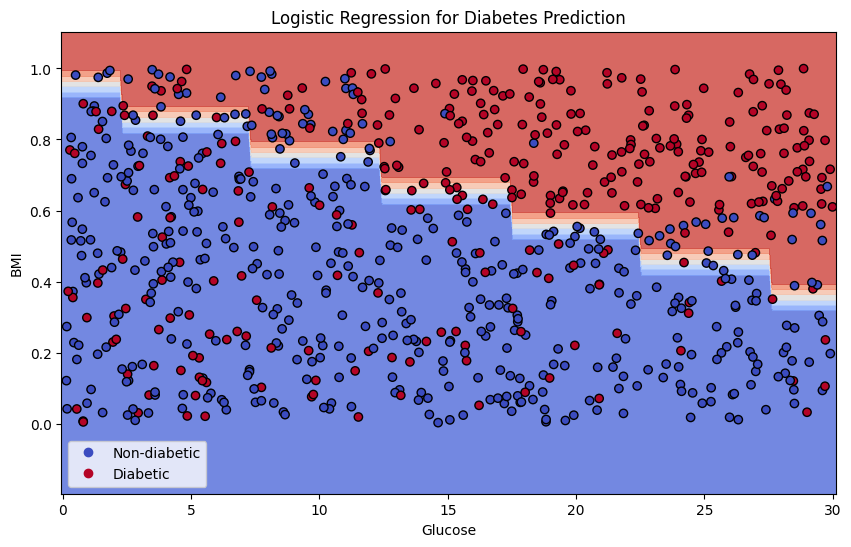

In [14]:
# Define the grid range based on your data
padding = 0.2
x_min, x_max = X[:, 0].min() - padding, X[:, 0].max() + padding
y_min, y_max = X[:, 1].min() - padding, X[:, 1].max() + padding

# Create a meshgrid
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))
# Predict the outcome on the meshgrid
Z2 = LR_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z2 = Z2.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z2, alpha=0.8, cmap=plt.cm.coolwarm)

# Plot the training points
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolor='k')
plt.xlabel('Glucose')
plt.ylabel('BMI')
plt.title('Logistic Regression for Diabetes Prediction')
plt.legend(handles=scatter.legend_elements()[0], labels=['Non-diabetic', 'Diabetic'])
plt.show()


In [15]:
# import xgboost
from xgboost import XGBClassifier

# declare the family (Gradient Boosting Classifier)
GB_model = XGBClassifier()

# fit the model on the training data
GB_model.fit(X, y)

# compute accuracy
y_pred_lr = GB_model.predict(X)
accuracy = accuracy_score(y, y_pred_lr)
print("Accuracy of Gradient Boosting:", accuracy)

Accuracy of Gradient Boosting: 0.97125


In [1]:
from sklearn.model_selection import train_test_split #function that splits the dataset into training and testing subsets


In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, shuffle=True, random_state=42) #Specifies that 25% of the data should be allocated to the test set
#Indicates that the data should be shuffled before splitting and sets the seed for the random number generator

In [17]:
d = 10 # depth of the tree

# Create a decision tree
deeptree = DecisionTreeClassifier(max_depth=d, random_state=42)

# Fit the model on the training data
deeptree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [18]:
# Make predictions
y_pred = deeptree.predict(X_train)

# Compute accuracy
accuracy = accuracy_score(y_train, y_pred)
print("Training accuracy of the deep decision tree:", accuracy)

Training accuracy of the deep decision tree: 0.92


In [19]:
# Make predictions
y_pred = deeptree.predict(X_test)

# Compute accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Testing accuracy of the deep decision tree:", accuracy)

Testing accuracy of the deep decision tree: 0.735


In [20]:
training_scores = [] #initialize an empty list
testing_scores = [] #initialize an empty list
depth_values = range(15) # create a range object representing integers 0 to 14
for depth in depth_values: #this loop runs 15 times
    dt = tree.DecisionTreeClassifier(max_depth=depth+1) #creates trees of depth 1 to 15
    dt.fit(X_train,y_train)
    train_score = dt.score(X_train,y_train) #calculates the accuracy of the model on the given dataset
    test_score = dt.score(X_test, y_test)
    training_scores.append(train_score) #add train score data to the training_scores list at each iteration
    testing_scores.append(test_score) #add test score data to the testing_scores list at each iteration

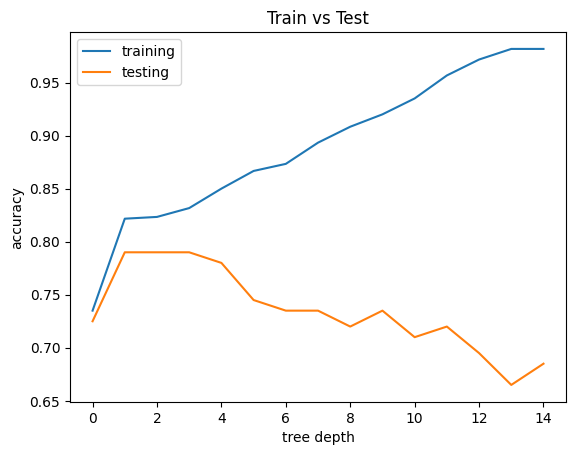

In [21]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()  # Create a figure containing a single axes.
ax.plot(training_scores,label='training')
ax.plot(testing_scores,label='testing')
ax.set_xlabel('tree depth')  # Add an x-label to the axes.
ax.set_ylabel('accuracy')  # Add a y-label to the axes.
ax.set_title("Train vs Test")  # Add a title to the axes.
ax.legend();  # Add a legend.

In [22]:
from xgboost import XGBClassifier

# Create a Gradient Boosting model
GB_model = XGBClassifier()

# Fit the model on the training data
GB_model.fit(X_train,y_train)

# Compute accuracy
y_pred_gb_train = GB_model.predict(X_train)
y_pred_gb_test = GB_model.predict(X_test)
accuracy_train = accuracy_score(y_train, y_pred_gb_train)
accuracy_test = accuracy_score(y_test, y_pred_gb_test)
print("Training Accuracy of Gradient Boosting:", accuracy_train)
print("Testing Accuracy of Gradient Boosting:", accuracy_test)

Training Accuracy of Gradient Boosting: 0.985
Testing Accuracy of Gradient Boosting: 0.695


## 2. Ορίζουμε το μοντέλο προς εκπαίδευση

In [32]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier

trees = {}
depths = 4

for level in ['easy', 'hard']:
    df = pd.read_csv(f'{level}_train_data.csv')
    print('Επίπεδο', level)
    #display(df)
    X = df.values[:,:-1]
    y = df.values[:,-1].astype(int)
    tree = DecisionTreeClassifier(max_depth=depths, random_state=42)
    tree.fit(X, y)
    print(f'Accuracy for depth {d}: {tree.score(X, y)}')
    print('Saving tree for level', level, 'with depth', d)
    trees[level] = tree

Επίπεδο easy
Accuracy for depth 5: 0.955
Saving tree for level easy with depth 5
Επίπεδο hard
Accuracy for depth 5: 0.95
Saving tree for level hard with depth 5


## 3. Αποθηκεύουμε τις απαντήσεις για υποβολή στο site

In [33]:
import json

def storeAnswers(trees):
    answers = {}
    for level in ['easy', 'hard']:
        clf = trees[level]
        try:
            answers[level] = {
                "children_left": clf.tree_.children_left.tolist(),
                "children_right": clf.tree_.children_right.tolist(),
                "feature": clf.tree_.feature.tolist(),
                "threshold": clf.tree_.threshold.tolist(),
                "label": clf.classes_[ clf.tree_.value[:,0].argmax(axis=-1) ].tolist()
            }
        except:
            print(f'{level}: Εκπαιδεύστε το δέντρο πριν το αποθηκεύσετε')

    with open('answers.json', 'w') as f:
        json.dump(answers, f)

storeAnswers(trees) # Κατεβάστε το αρχείο 'answers.json' για υποβολή στο site

In [ ]:
from google.colab import files
files.download('answers.json')